# Fall 2024: IMSE 586 - 001 (Big Data Analytics and Visualization)
### Final Project: Predicting 30-Day Hospital Readmissions in Diabetic Patients

### Importing Libraries


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV,cross_val_score
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn import preprocessing
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score,confusion_matrix, recall_score, precision_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import shap

### Data processing and transformation

### Importing the Dataset

In [3]:
healthcare_dataset = pd.read_csv("./diabetic_data.csv")
healthcare_dataset.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Data Exploration

In [4]:
#column names
healthcare_dataset.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [5]:
healthcare_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
healthcare_dataset.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [7]:
# Checking for missing values
for col in healthcare_dataset.columns:
    if healthcare_dataset[col].dtype == object:
         print(col,healthcare_dataset[col][healthcare_dataset[col] == '?'].count())
#The missing values are represented as '?' sign in the source dataset       

race 2273
gender 0
age 0
weight 98569
payer_code 40256
medical_specialty 49949
diag_1 21
diag_2 358
diag_3 1423
max_glu_serum 0
A1Cresult 0
metformin 0
repaglinide 0
nateglinide 0
chlorpropamide 0
glimepiride 0
acetohexamide 0
glipizide 0
glyburide 0
tolbutamide 0
pioglitazone 0
rosiglitazone 0
acarbose 0
miglitol 0
troglitazone 0
tolazamide 0
examide 0
citoglipton 0
insulin 0
glyburide-metformin 0
glipizide-metformin 0
glimepiride-pioglitazone 0
metformin-rosiglitazone 0
metformin-pioglitazone 0
change 0
diabetesMed 0
readmitted 0


### Separating Categorical and Continuous columns

In [8]:
# Separate Categorical and Continuous variables
categorical_columns, continuous_columns=[],[]

for i in healthcare_dataset.columns:
    
    if healthcare_dataset[i].dtype == 'object':
        categorical_columns.append(i)
    else:
        continuous_columns.append(i)
        
print("Categorical Columns:\n",categorical_columns)
print("\n")
print("Continous Columns:\n",continuous_columns)

Categorical Columns:
 ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


Continous Columns:
 ['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


### Target Variable - "readmitted"

In [9]:
# We are combining the "readmission after 30 days" and "no readmission" into a single category in order to simplify it to a binary format.
healthcare_dataset['readmitted'] = healthcare_dataset['readmitted'].replace('>30', 0)
healthcare_dataset['readmitted'] = healthcare_dataset['readmitted'].replace('<30', 1)
healthcare_dataset['readmitted'] = healthcare_dataset['readmitted'].replace('NO', 0)
print(healthcare_dataset.readmitted)

0         0
1         0
2         0
3         0
4         0
         ..
101761    0
101762    0
101763    0
101764    0
101765    0
Name: readmitted, Length: 101766, dtype: int64


In [10]:
#Total count of "readmission" and "no readmission"
counts = healthcare_dataset['readmitted'].value_counts()
print("Count of 1 (readmission):", counts.get(1, 0))
print("Count of 0 (no readmission):", counts.get(0, 0))


Count of 1 (readmission): 11357
Count of 0 (no readmission): 90409


### Removing the columns: weight, Payer code,medical speciality, encounter_id, examide and citoglipton

In [11]:
#Removing columns with large number of missing values
healthcare_dataset = healthcare_dataset.drop(['weight','payer_code','medical_specialty'], axis = 1)


In [12]:
#Removing columns "encounter_id", "examide" and "citogliptonas" they are not going to effect model, as they have either unique or same values
healthcare_dataset = healthcare_dataset.drop(['encounter_id','citoglipton', 'examide'], axis = 1)
healthcare_dataset.head(5)


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,...,No,No,No,No,No,No,No,No,No,0
1,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,No,No,No,No,No,No,No,No,Yes,0
3,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,...,No,Steady,No,No,No,No,No,Ch,Yes,0


### Managing missing values from Race, diag 1, diag 2, diag 3, and gender variables

In [13]:
# Race, diag 1, diag 2, diag 3, and gender columns have only few missing values than the other attributes we omitted 
#therefore we are just removing these rows.
healthcare_dataset_cleandata = set(healthcare_dataset.index[(
    (healthcare_dataset['diag_1'] == '?') & (healthcare_dataset['diag_2'] == '?') & (healthcare_dataset['diag_3'] == '?')) |
    (healthcare_dataset['diag_1'] == '?') |
    (healthcare_dataset['diag_2'] == '?') |
    (healthcare_dataset['diag_3'] == '?') |
    (healthcare_dataset['race'] == '?') |
    (healthcare_dataset['discharge_disposition_id'] == 11) |
    (healthcare_dataset['gender'] == 'Unknown/Invalid')
])

# Filtering the dataset
new_healthcare_dataset_cleandata = list(set(healthcare_dataset.index) - healthcare_dataset_cleandata)
healthcare_dataset = healthcare_dataset.iloc[new_healthcare_dataset_cleandata]


In [14]:
#Checking for missing values in the data that are managed in the above cell
for col in healthcare_dataset.columns:
    if healthcare_dataset[col].dtype == object:
         print(col,healthcare_dataset[col][healthcare_dataset[col] == '?'].count())
            
print('gender', healthcare_dataset['gender'][healthcare_dataset['gender'] == 'Unknown/Invalid'].count())   

race 0
gender 0
age 0
diag_1 0
diag_2 0
diag_3 0
max_glu_serum 0
A1Cresult 0
metformin 0
repaglinide 0
nateglinide 0
chlorpropamide 0
glimepiride 0
acetohexamide 0
glipizide 0
glyburide 0
tolbutamide 0
pioglitazone 0
rosiglitazone 0
acarbose 0
miglitol 0
troglitazone 0
tolazamide 0
insulin 0
glyburide-metformin 0
glipizide-metformin 0
glimepiride-pioglitazone 0
metformin-rosiglitazone 0
metformin-pioglitazone 0
change 0
diabetesMed 0
gender 0


### Managing data related to the 23 medications given in the dataset

In [15]:
# A change in the drug taken during the patient's current hospital stay is indicated for each of the 23 medications in the dataset. 
# Research has shown that altering a diabetic patient's medication regimen after admission decreases the readmission rate. 
# We are calculating the number of drugs for each patient whose status changed from 'No' or 'Steady'. 
# Finally suming these changes into a new column "Drug_change" which shows how many patients had 0, 1, 2, etc., drug changes.

drugs23_heathcare = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin', 'glyburide-metformin', 'tolazamide', 'metformin-pioglitazone','metformin-rosiglitazone', 'glimepiride-pioglitazone', 'glipizide-metformin', 'troglitazone', 'tolbutamide', 'acetohexamide']
for col in drugs23_heathcare:
    colname = str(col) + 'temp'
    healthcare_dataset[colname] = healthcare_dataset[col].apply(lambda x: 0 if (x == 'No' or x == 'Steady') else 1)
healthcare_dataset['Drug_change'] = 0
for col in drugs23_heathcare:
    colname = str(col) + 'temp'
    healthcare_dataset['Drug_change'] = healthcare_dataset['Drug_change'] + healthcare_dataset[colname]
    del healthcare_dataset[colname]
    
healthcare_dataset['Drug_change'].value_counts()  

Drug_change
0    70142
1    24922
2     1271
3      106
4        5
Name: count, dtype: int64

### Encoding: gender, race, medication change, and each of the 23 drugs columns in the dataset

In [16]:
# The dataset uses string values for each of these columns.
# To fit them into our model, we are interpreting the variables as binary variables.
change_map = {'Ch': 1, 'No': 0}
gender_map = {'Male': 1, 'Female': 0}
diabetesMed_map = {'Yes': 1, 'No': 0}
drug_map = {'No': 0, 'Steady': 1, 'Up': 1, 'Down': 1}

# Apply the mappings
healthcare_dataset['change'] = healthcare_dataset['change'].replace(change_map)
healthcare_dataset['gender'] = healthcare_dataset['gender'].replace(gender_map)
healthcare_dataset['diabetesMed'] = healthcare_dataset['diabetesMed'].replace(diabetesMed_map)

# Loop through drugs23_heathcare columns and apply the drug_map
for col in drugs23_heathcare:
    healthcare_dataset[col] = healthcare_dataset[col].replace(drug_map)

In [17]:
#Diplaying the encoded columns
print("Updated 'change' column:")
print(healthcare_dataset['change'].value_counts())

print("\nUpdated 'gender' column:")
print(healthcare_dataset['gender'].value_counts())

print("\nUpdated 'diabetesMed' column:")
print(healthcare_dataset['diabetesMed'].value_counts())

Updated 'change' column:
change
0    51719
1    44727
Name: count, dtype: int64

Updated 'gender' column:
gender
0    52006
1    44440
Name: count, dtype: int64

Updated 'diabetesMed' column:
diabetesMed
1    74290
0    22156
Name: count, dtype: int64


In [18]:
# Creating a new column "drug_count" to track the total number of medications each patient is prescribed.
healthcare_dataset['drug_count'] = 0

for col in drugs23_heathcare:
    healthcare_dataset['drug_count'] = healthcare_dataset['drug_count'] + healthcare_dataset[col]
healthcare_dataset['drug_count'].value_counts()

drug_count
1    44589
0    22156
2    20901
3     7448
4     1290
5       57
6        5
Name: count, dtype: int64

### Encoding admission type, discharge type and admission source columns based up on the mapping dataset

In [19]:
# Encoding "admission type", "discharge type" and "admission source" into fewer categories by using mapping
admission_type_map = {2: 1, 7: 1, 6: 5, 8: 5}
discharge_disposition_map = {6: 1, 8: 1, 9: 1, 13: 1, 3: 2, 4: 2, 5: 2, 14: 2, 
                             22: 2, 23: 2, 24: 2, 12: 10, 15: 10, 16: 10, 17: 10, 
                             25: 18, 26: 18}
admission_source_map = {2: 1, 3: 1, 5: 4, 6: 4, 10: 4, 22: 4, 25: 4, 15: 9, 
                        17: 9, 20: 9, 21: 9, 13: 11, 14: 11}

# Apply the mappings
healthcare_dataset['admission_type_id'] = healthcare_dataset['admission_type_id'].replace(admission_type_map)
healthcare_dataset['discharge_disposition_id'] = healthcare_dataset['discharge_disposition_id'].replace(discharge_disposition_map)
healthcare_dataset['admission_source_id'] = healthcare_dataset['admission_source_id'].replace(admission_source_map)

In [20]:
#Diplaying the encoded columns
print("Encoded Admission Type IDs:")
print(healthcare_dataset['admission_type_id'].value_counts())

print("\nEncoded Discharge Disposition IDs:")
print(healthcare_dataset['discharge_disposition_id'].value_counts())

print("\nEncoded Admission Source IDs:")
print(healthcare_dataset['admission_source_id'].value_counts())

Encoded Admission Type IDs:
admission_type_id
1    68414
3    18070
5     9952
4       10
Name: count, dtype: int64

Encoded Discharge Disposition IDs:
discharge_disposition_id
1     70758
2     20282
18     4565
7       592
28      137
10       97
19        8
27        5
20        2
Name: count, dtype: int64

Encoded Admission Source IDs:
admission_source_id
7     54847
1     29308
9      6676
4      5596
8        14
11        5
Name: count, dtype: int64


 ### Encoding Age column

In [21]:
# For better reference we are chaning the ranges of the age column to numerical values.
# If the patient falls into the 10–20 year age range, we are considering as the patient is 15 years old.
for i in range(0,10):
    healthcare_dataset['age'] = healthcare_dataset['age'].replace('['+str(10*i)+'-'+str(10*(i+1))+')', i+1)
age_dict = {1:5, 2:15, 3:25, 4:35, 5:45, 6:55, 7:65, 8:75, 9:85, 10:95}
healthcare_dataset['age'] = healthcare_dataset.age.map(age_dict)
print(healthcare_dataset['age'].value_counts().sort_index())


age
5        64
15      466
25     1471
35     3538
45     9208
55    16546
65    21521
75    24815
85    16223
95     2594
Name: count, dtype: int64


### Encoding: A1CResult and max_glu_serum columns


In [22]:
#We are dividing the values of the A1CResult and max_glu_serum columns into three categories: Normal, Abnormal, and Not tested.

A1Cresult_map = {'>7': 1, '>8': 1, 'Norm': 0, 'None': -99}
max_glu_serum_map = {'>200': 1, '>300': 1, 'Norm': 0, 'None': -99}

# Apply the mappings
healthcare_dataset['A1Cresult'] = healthcare_dataset['A1Cresult'].replace(A1Cresult_map)
healthcare_dataset['max_glu_serum'] = healthcare_dataset['max_glu_serum'].replace(max_glu_serum_map)

print(healthcare_dataset['A1Cresult'].value_counts())
print(healthcare_dataset['max_glu_serum'].value_counts())

A1Cresult
1.0    11247
0.0     4806
Name: count, dtype: int64
max_glu_serum
1.0    2579
0.0    2510
Name: count, dtype: int64


### Managing columns: "diag_1", "diag_2" and "diag_3"

In [23]:
# diag_1 represents the primary diagnosis code for a patient, typically the main reason for admission.
# diag_2 represents the secondary diagnosis code, that may be present but are less significant than the primary diagnosis.
# diag_3 represents the tertiary diagnosis code, usually less critical conditions that might influence the patient's or treatment.
# Hence we are dropping the columns diag_2 and diag_3 as they are not significant.
healthcare_dataset.drop(['diag_2', 'diag_3'], axis=1, inplace=True)

### Encoding diag_1 column

ICD-9 (International Classification of Diseases, Ninth Revision) is a coding system used in healthcare to classify and code diagnoses, 
symptoms, and procedures. According to the ICD 9 codes - “circulatory” for icd9: 390–459, 785, “digestive” for icd9: 520–579, 787, 
“genitourinary” for icd9: 580–629, 788, “diabetes” for icd9: 250.xx, “injury” for icd9: 800–999, “musculoskeletal” for icd9: 710–739,
“neoplasms” for icd9: 140–239, “respiratory’’ for icd9: 460–519, 786, and “other” for otherwise.

In [24]:
# Using the ICD-9 codes we are creating levels for diagonis 1(level1_diagnosis1 and level2_diagnosis1).
# level1_diagnosis1: Primary or the most critical conditions (e.g., heart disease, cancer).
# level2_diagnosis1: Secondary complications or less severe conditions (e.g., hypertension, diabetes).

# Creating 'level1_diagnosis1' and 'level2_diagnosis1' columns by copying values from the 'diag_1' column
healthcare_dataset['level1_diagnosis1'] = healthcare_dataset['diag_1']
healthcare_dataset['level2_diagnosis1'] = healthcare_dataset['diag_1']

# Changing 'level1_diagnosis1' and 'level2_diagnosis1' to 0 where 'diag_1' contains 'V' or 'E' codes
healthcare_dataset.loc[healthcare_dataset['diag_1'].str.contains('V'), ['level1_diagnosis1', 'level2_diagnosis1']] = 0
healthcare_dataset.loc[healthcare_dataset['diag_1'].str.contains('E'), ['level1_diagnosis1', 'level2_diagnosis1']] = 0

# Replacing '?' values in 'level1_diagnosis1' and 'level2_diagnosis1' with -1, indicating missing or undefined diagnoses
healthcare_dataset['level1_diagnosis1'] = healthcare_dataset['level1_diagnosis1'].replace('?', -1)
healthcare_dataset['level2_diagnosis1'] = healthcare_dataset['level2_diagnosis1'].replace('?', -1)

# Converting the 'level1_diagnosis1' and 'level2_diagnosis1' columns to float type for numerical operations
healthcare_dataset['level1_diagnosis1'] = healthcare_dataset['level1_diagnosis1'].astype(float)
healthcare_dataset['level2_diagnosis1'] = healthcare_dataset['level2_diagnosis1'].astype(float)



In [25]:
# Defining a function to apply the mapping logic
def map_diag_level(value, level=1):
    
    # Defining the mapping for level 1 and level 2 diagnoses
    if level == 1:
        mapping = {
            (390, 460): 1,
            (460, 520): 2,
            (520, 580): 3,
            (250, 250): 4,
            (800, 1000): 5,
            (710, 740): 6,
            (580, 630): 7,
            (140, 240): 8
        }
    elif level == 2:
        mapping = {
            (390, 399): 1,
            (401, 415): 2,
            (415, 460): 3,
            (785, 785): 4,
            (460, 489): 5,
            (490, 497): 6,
            (500, 520): 7,
            (786, 786): 8,
            (520, 530): 9,
            (530, 544): 10,
            (550, 554): 11,
            (555, 580): 12,
            (787, 787): 13,
            (250, 250): 14,
            (800, 1000): 15,
            (710, 740): 16,
            (580, 630): 17,
            (788, 788): 18,
            (140, 240): 19,
            (240, 280): 20,
            (680, 710): 21,
            (290, 320): 22
        }
    
    # Checking the value against the mapping ranges
    for range_tuple, label in mapping.items():
        if range_tuple[0] <= value < range_tuple[1]:
            return label
    
    # Default case if no range is matched
    return 0

# Applying the mapping for 'level1_diag1' and 'level2_diag1'
healthcare_dataset['level1_diagnosis1'] = healthcare_dataset['level1_diagnosis1'].apply(map_diag_level, level=1)
healthcare_dataset['level2_diagnosis1'] = healthcare_dataset['level2_diagnosis1'].apply(map_diag_level, level=2)

display_columns = healthcare_dataset[['level1_diagnosis1', 'level2_diagnosis1', 'diag_1', ]] 
display(display_columns)


,level1_diagnosis1,level2_diagnosis1,diag_1
1,0,20,276
2,0,0,648
3,0,0,8
4,8,19,197
5,1,2,414
...,...,...,...
101761,0,20,250.13
101762,3,12,560
101763,0,0,38
101764,5,15,996


In [26]:
# Droping the 'level2_diagnosis1' and 'diag_1' column since it is redundant and unnecessary for the analysis
healthcare_dataset.drop(['level2_diagnosis1','diag_1'], axis=1, inplace=True)


In [27]:
# Converting the data type of nominal features into 'object'
index = [ 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
          'age',  'max_glu_serum', 'level1_diagnosis1',]

healthcare_dataset[index] = healthcare_dataset[index].astype('object')
healthcare_dataset.info()


<class 'pandas.core.frame.DataFrame'>
Index: 96446 entries, 1 to 101765
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_nbr               96446 non-null  int64  
 1   race                      96446 non-null  object 
 2   gender                    96446 non-null  object 
 3   age                       96446 non-null  object 
 4   admission_type_id         96446 non-null  object 
 5   discharge_disposition_id  96446 non-null  object 
 6   admission_source_id       96446 non-null  object 
 7   time_in_hospital          96446 non-null  int64  
 8   num_lab_procedures        96446 non-null  int64  
 9   num_procedures            96446 non-null  int64  
 10  num_medications           96446 non-null  int64  
 11  number_outpatient         96446 non-null  int64  
 12  number_emergency          96446 non-null  int64  
 13  number_inpatient          96446 non-null  int64  
 14  number_dia

In [28]:
# Encoding Categorical Variables
CV = preprocessing.LabelEncoder()
healthcare_dataset['race'] = CV.fit_transform(healthcare_dataset['race'])
healthcare_dataset['gender'] = CV.fit_transform(healthcare_dataset['gender'])
healthcare_dataset['age'] = CV.fit_transform(healthcare_dataset['age'])
healthcare_dataset['admission_source_id'] = CV.fit_transform(healthcare_dataset['admission_source_id'])
healthcare_dataset['discharge_disposition_id'] = CV.fit_transform(healthcare_dataset['discharge_disposition_id'])
healthcare_dataset['level1_diagnosis1'] = CV.fit_transform(healthcare_dataset['level1_diagnosis1'])
healthcare_dataset['max_glu_serum'] = CV.fit_transform(healthcare_dataset['max_glu_serum'])
healthcare_dataset['admission_type_id'] = CV.fit_transform(healthcare_dataset['admission_type_id'])

healthcare_dataset

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,Drug_change,drug_count,level1_diagnosis1
1,55629189,2,0,1,0,0,2,3,59,0,...,0,0,0,0,1,1,0,1,1,0
2,86047875,0,0,2,0,0,2,2,11,5,...,0,0,0,0,0,1,0,0,1,0
3,82442376,2,1,3,0,0,2,2,44,1,...,0,0,0,0,1,1,0,1,1,0
4,42519267,2,1,4,0,0,2,1,51,0,...,0,0,0,0,1,1,0,0,2,7
5,82637451,2,1,5,0,0,0,3,31,6,...,0,0,0,0,0,1,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,100162476,0,1,7,0,1,2,3,51,0,...,0,0,0,0,1,1,0,1,2,0
101762,74694222,0,0,8,0,1,1,5,33,3,...,0,0,0,0,0,1,0,0,1,3
101763,41088789,2,1,7,0,0,2,1,53,0,...,0,0,0,0,1,1,0,1,2,0
101764,31693671,2,0,8,0,1,2,10,45,2,...,0,0,0,0,1,1,0,1,3,4


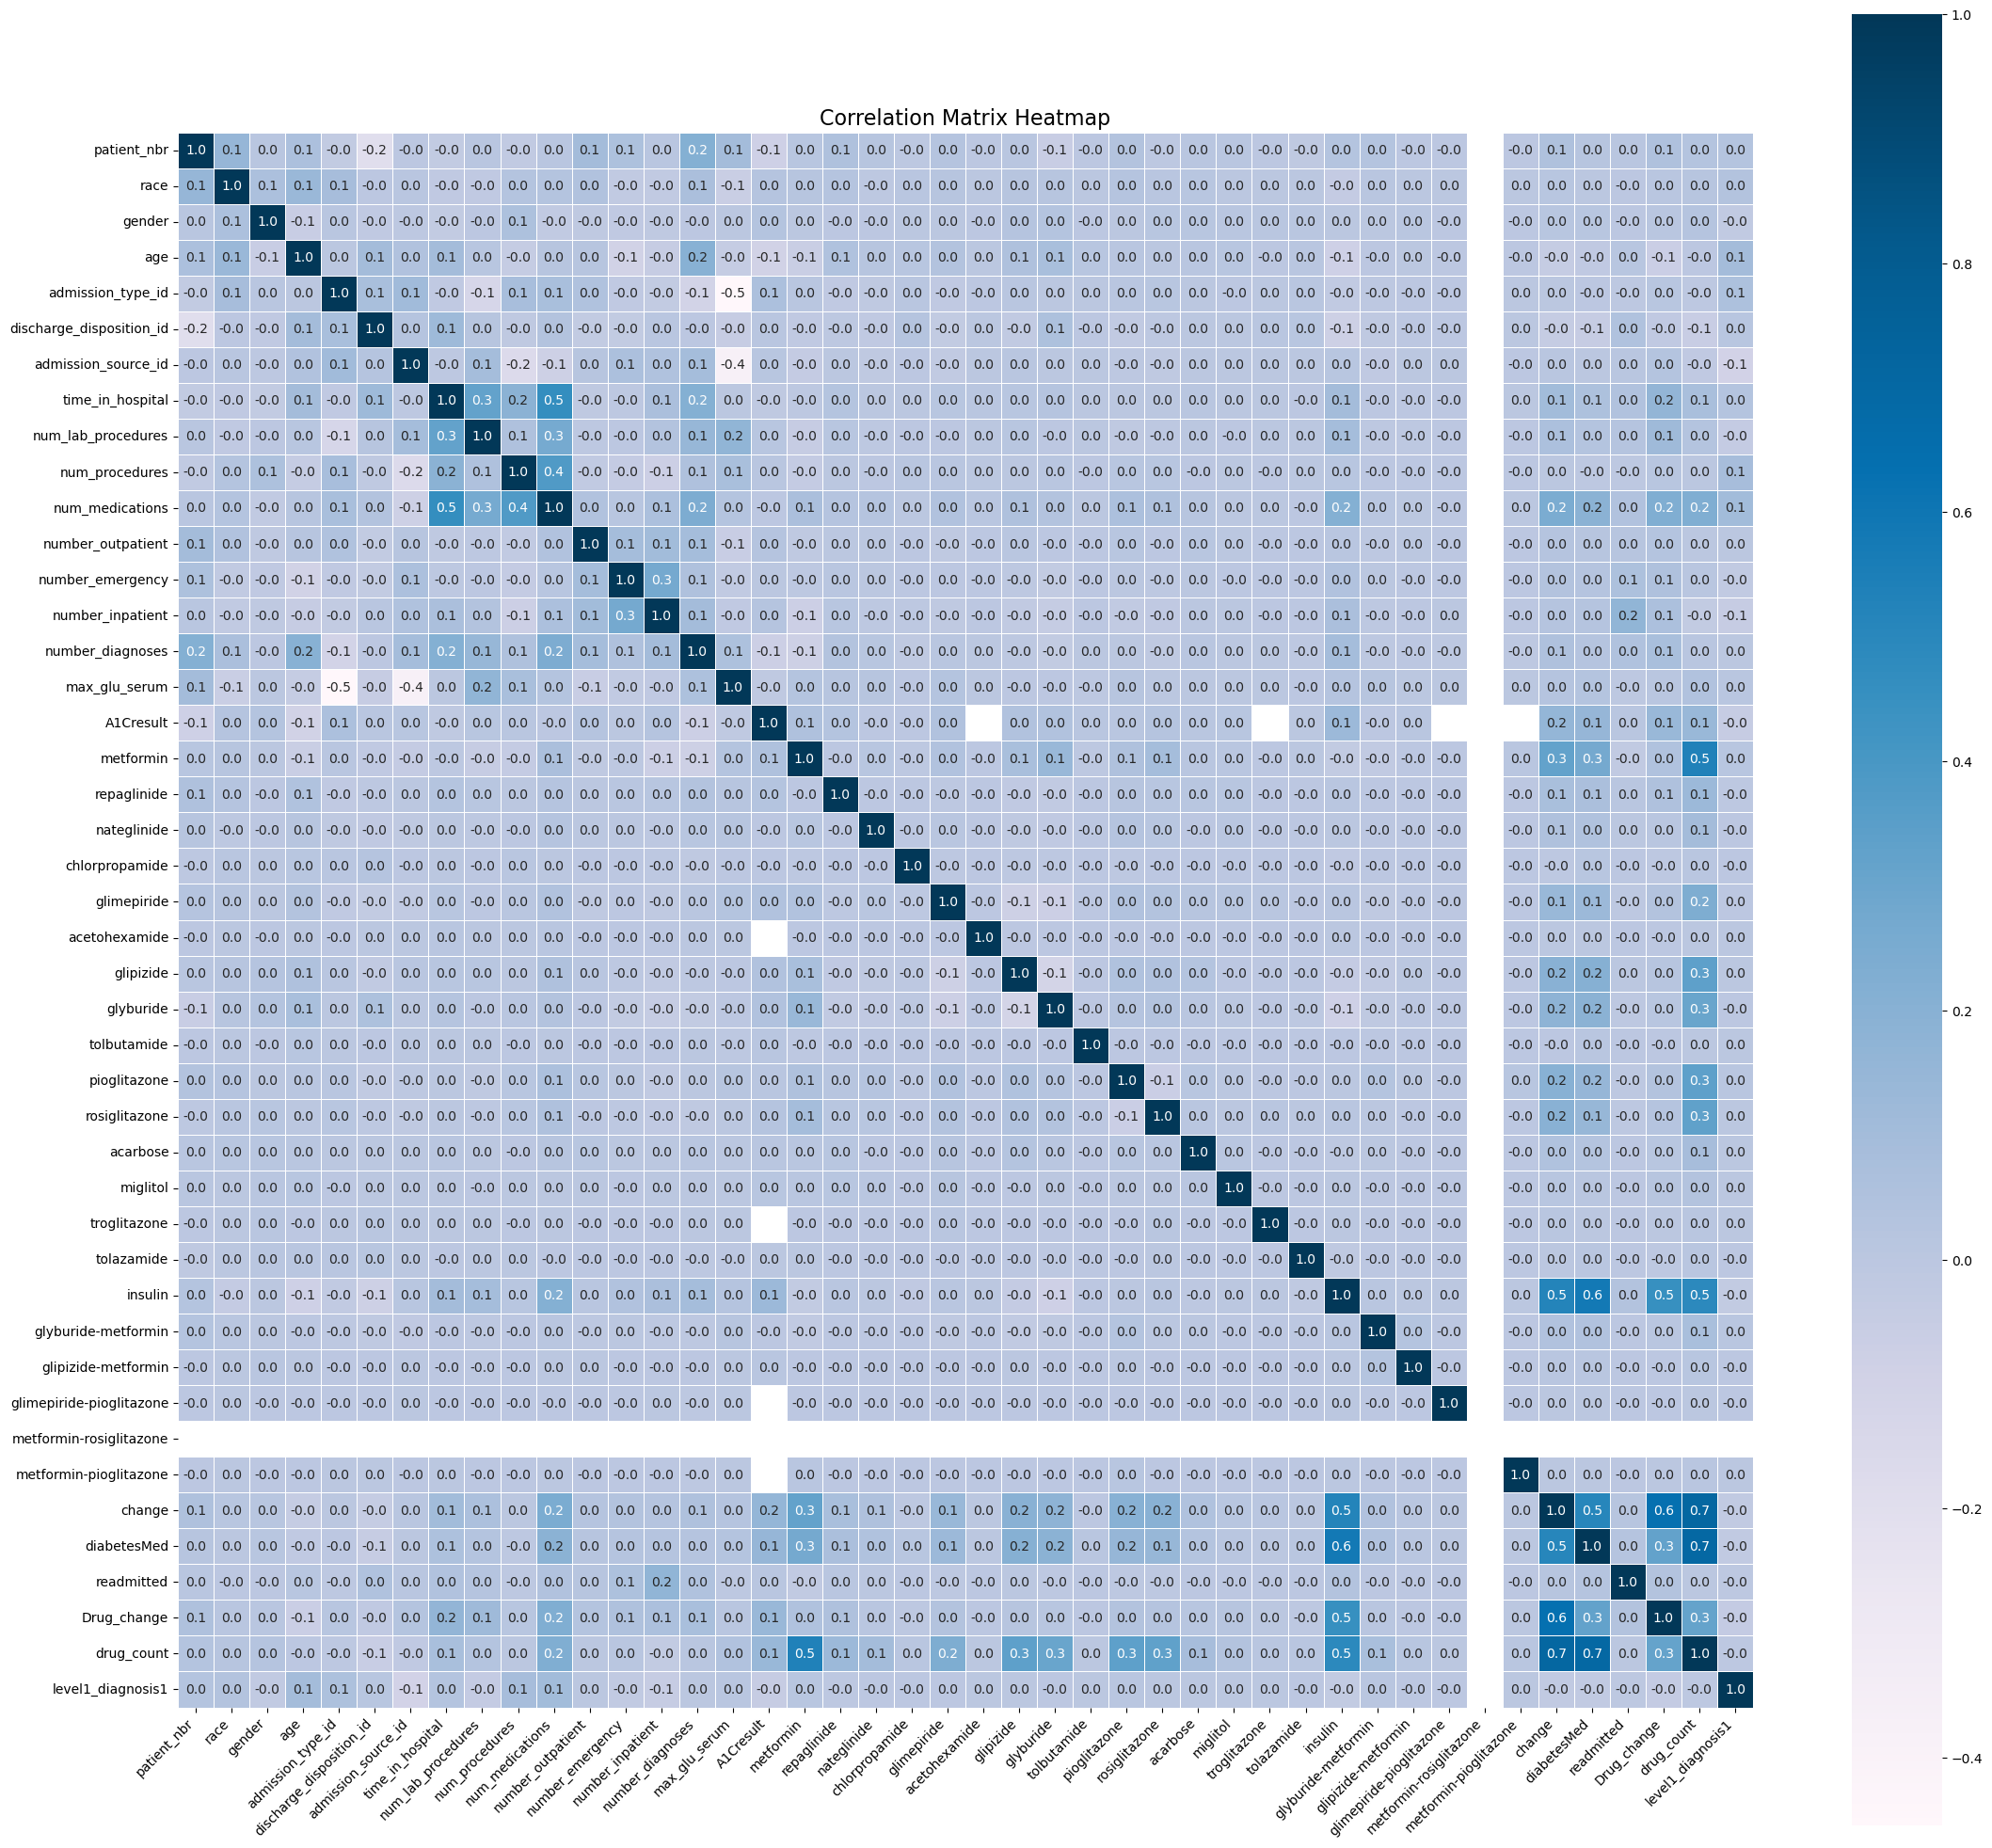

In [29]:
# Checking coorelation between the columns

plt.figure(figsize=(27,25))
ax = sns.heatmap(healthcare_dataset.corr(), square=True, annot=True, fmt='.1f', cmap='PuBu',linewidths=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix Heatmap', fontsize=16)         
plt.show()

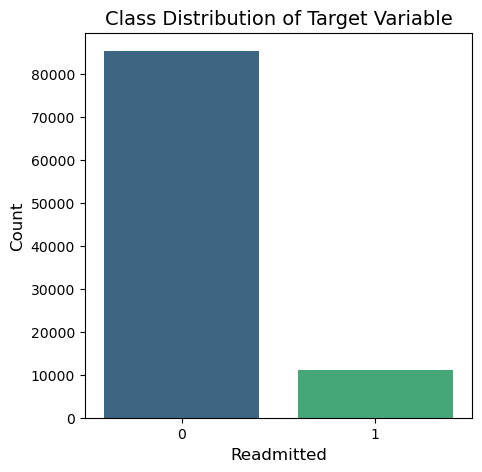

In [30]:
# Checking Data Imbalance in the Target Variable
plt.figure(figsize=(5, 5))
sns.countplot(data=healthcare_dataset, x='readmitted', palette='viridis')
plt.title('Class Distribution of Target Variable', fontsize=14)
plt.xlabel('Readmitted', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

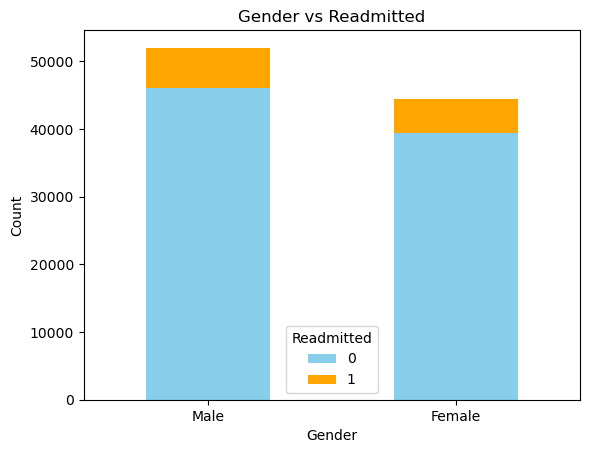

In [31]:
# Group by 'gender' and 'readmitted', then unstack to create a dataframe
gender_readmitted = healthcare_dataset.groupby(['gender', 'readmitted']).size().unstack()

# Plot the stacked bar chart
gender_readmitted.plot(kind='bar', stacked=True, color=['skyblue', 'orange'])

# Set title and labels
plt.title('Gender vs Readmitted')
plt.xlabel('Gender')
plt.ylabel('Count')

# Set proper x-tick labels if needed (e.g., for male/female)
plt.xticks([0, 1], ['Male', 'Female'], rotation=0)

# Add legend with title 'Readmitted'
plt.legend(title='Readmitted')

# Display the plot
plt.show()

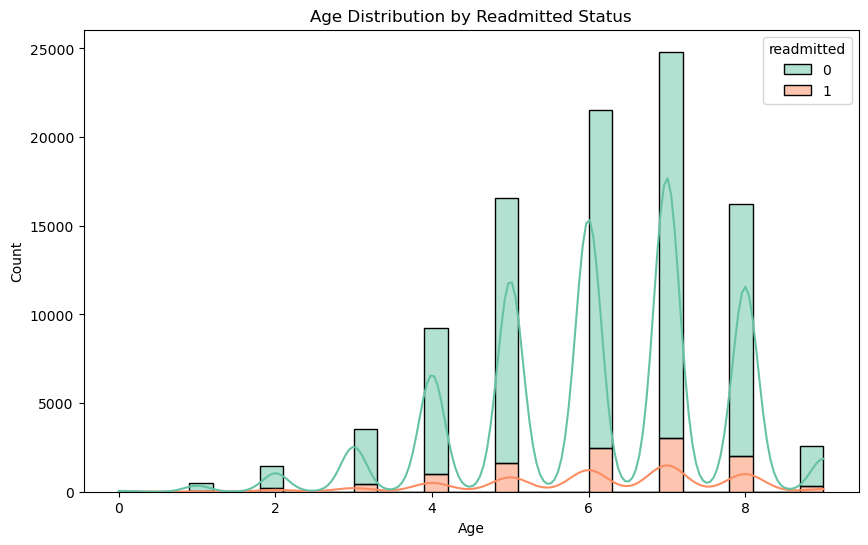

In [32]:
#Plot histograms for age distribution by readmitted status
plt.figure(figsize=(10, 6))
sns.histplot(data=healthcare_dataset, x='age', hue='readmitted', kde=True, palette='Set2', multiple='stack', bins=30)

# Setting title and labels
plt.title('Age Distribution by Readmitted Status')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

In [33]:
# Splitting the data into Train and Test 
train_set, test_set = train_test_split(healthcare_dataset, test_size=0.3, random_state=1)

# Verifying the split
print(f"Training data shape: {train_set.shape}")
print(f"Testing data shape: {test_set.shape}")

Training data shape: (67512, 44)
Testing data shape: (28934, 44)


In [34]:
#Checking the Counts of Train and Test Data
no_count, yes_count = train_set.readmitted.value_counts()
print(no_count, yes_count)

59764 7748


In [35]:
# Managing Data Imbalance using Over Sampling
# Using oversampling by duplicating instances where readmitted == 1 to balance the target variable classes in the training dataset.
readmitted_target_set  = train_set.loc[train_set.readmitted==1]
oversampled_set = readmitted_target_set.sample(n=(no_count-yes_count),replace=True)

train_set = pd.concat([train_set, oversampled_set], ignore_index=True)
train_set.readmitted.value_counts()


readmitted
0    59764
1    59764
Name: count, dtype: int64

### Scaling

In [36]:
# Defining our target variable
target = 'readmitted'
df2=healthcare_dataset.drop(columns=['A1Cresult'])
# Creating a list of predictor variables (all columns except the target variable)
predictors = list(df2.columns)
# Remove the target column from the list of predictors
predictors.remove(target)

# Initializing a StandardScaler to normalize the predictor variables
scaler = preprocessing.StandardScaler()

# Fitting the scaler to the predictor variables in the entire dataset, which calculates the mean and standard deviation for each predictor.
scaler.fit(healthcare_dataset[predictors])

# Transforming the predictor variables in the training set using the fitted scaler
train_predictors = scaler.transform(train_set[predictors])

# Extracting the target variable from the training set
train_target = train_set[target]

# Transforming the predictor variables in the test set using the same scaler, which the test data is scaled based on training data.
test_predictors = scaler.transform(test_set[predictors])

# Extracting the target variable from the test set
test_target= test_set[target] 


### Train our models

### Logistic regression model

In [37]:
#Instantiating Logistic Regression Model 
clf = LogisticRegression(random_state=1)

#Fitting our training data into the model
clf.fit(train_predictors, train_target)

#Making predictions using the test dataset.
logreg_predictions = clf.predict(test_predictors)

###  Using `predict_proba` method in Logistic Regression

The `predict_proba` method is used to predicte probabilities for both classes(0,1), wheere class 0 represents the no redadmission and class 1 represents thelikelihood of readmission.

In [38]:
#probability of the target varibale belonging to class 0 representing likelihood of no readmission
clf.predict_proba(test_predictors)[:,0]

array([0.36571187, 0.28726914, 0.61600157, ..., 0.51067133, 0.40052273,
       0.57417536])

In [39]:
#probability of the target varibale belonging to class 0 representinglikelihood of readmission
clf.predict_proba(test_predictors)[:,1]

array([0.63428813, 0.71273086, 0.38399843, ..., 0.48932867, 0.59947727,
       0.42582464])

### Accuracy Score of the Logistic Regression model

In [40]:
#accuracy of the model on test dataset
accu_score = accuracy_score(test_target, logreg_predictions)
print("Accuracy Score of Logistic Regression Model on test dataset:{0:0.4f}" .format(accu_score))

Accuracy Score of Logistic Regression Model on test dataset:0.6611


### Confusion Matrix of logistic regression model

In [41]:
# Compute the confusion matrix
cm =confusion_matrix(test_target, logreg_predictions)
print('Confusion matrix\n', cm)

# Extracting TP, TN, FP, FN
TP = cm[1,1]# True Positives: Correctly predicted positive cases
TN = cm[0,0]# True Negatives: Correctly predicted negative cases
FP = cm[0,1]# False Positives: Incorrectly predicted as positive
FN = cm[1,0]# False Negatives: Missed positive cases

# Printing the values for each metric
print('\nTrue Positives(TP) = ', TP)

print('\nTrue Negatives(TN) = ', TN)

print('\nFalse Positives(FP) = ', FP)

print('\nFalse Negatives(FN) = ', FN)

# Calculate and print the recall score, accuracy score, Precesion score and F1 score
print('\nRecall Score {0:.4f}\n'.format(recall_score(test_target, logreg_predictions)))

print('Accuracy Score {0:.4f}\n'.format(accu_score))

print('Precision Score {0:.4f}\n'.format(precision_score(test_target, logreg_predictions)))

print('F1 Score {0:.4f}\n'.format(f1_score(test_target, logreg_predictions)))


Confusion matrix
 [[17444  8172]
 [ 1634  1684]]

True Positives(TP) =  1684

True Negatives(TN) =  17444

False Positives(FP) =  8172

False Negatives(FN) =  1634

Recall Score 0.5075

Accuracy Score 0.6611

Precision Score 0.1709

F1 Score 0.2557



### Decision Tree model

In [42]:
#Instantiating Decision Tree Model 
d_tree = DecisionTreeClassifier(random_state=1)

#Fitting our training data into the model
d_tree.fit(train_predictors, train_target)

#Making predictions using the test dataset.
dtree_predictions = d_tree.predict(test_predictors)



### Confusion Matrix for Decision Tree Model

In [43]:
# Compute the confusion matrix for the decision tree model
cm = confusion_matrix(test_target, dtree_predictions)
print('Confusion matrix\n', cm)

# Extract values from the confusion matrix
TP = cm[1, 1]  # True Positives: Correctly predicted positive cases
TN = cm[0, 0]  # True Negatives: Correctly predicted negative cases
FP = cm[0, 1]  # False Positives: Incorrectly predicted as positive
FN = cm[1, 0]  # False Negatives: Missed positive cases

# Print the values for each metric
print('\nTrue Positives(TP) = ', TP)  # Display the number of true positives
print('\nTrue Negatives(TN) = ', TN)  # Display the number of true negatives
print('\nFalse Positives(FP) = ', FP)  # Display the number of false positives
print('\nFalse Negatives(FN) = ', FN)  # Display the number of false negatives

# Calculate and print the recall score, accuracy score, Precesion score and F1 score
print('\nRecall Score {0:.4f}\n'.format(recall_score(test_target, dtree_predictions)))

print('Accuracy Score {0:.4f}\n'.format(accuracy_score(test_target, dtree_predictions)))

print('Precision Score {0:.4f}\n'.format(precision_score(test_target, dtree_predictions)))

print('F1 Score {0:.4f}\n'.format(f1_score(test_target, dtree_predictions)))


Confusion matrix
 [[22677  2939]
 [ 2792   526]]

True Positives(TP) =  526

True Negatives(TN) =  22677

False Positives(FP) =  2939

False Negatives(FN) =  2792

Recall Score 0.1585

Accuracy Score 0.8019

Precision Score 0.1518

F1 Score 0.1551



### XGBoost Model

In [44]:
# Initialize the XGBoost model
xgboost_model = XGBClassifier(random_state=1)

# Fit the model on the training data
xgboost_model.fit(train_predictors, train_target)

# Predict on the test data
xgboost_predictions = xgboost_model.predict(test_predictors)

### Confusion Matrix for XGBoost Model

In [45]:
# Compute the confusion matrix for the XGBoost model
cm = confusion_matrix(test_target, xgboost_predictions)
print('Confusion matrix\n', cm)

# Extract values from the confusion matrix
TP = cm[1, 1]  # True Positives: Correctly predicted positive cases
TN = cm[0, 0]  # True Negatives: Correctly predicted negative cases
FP = cm[0, 1]  # False Positives: Incorrectly predicted as positive
FN = cm[1, 0]  # False Negatives: Missed positive cases

# Print the values for each confusion matrix component
print('\nTrue Positives(TP) = ', TP)  # Display the number of true positives
print('\nTrue Negatives(TN) = ', TN)  # Display the number of true negatives
print('\nFalse Positives(FP) = ', FP)  # Display the number of false positives
print('\nFalse Negatives(FN) = ', FN)  # Display the number of false negatives

print('\nRecall Score {0:.4f}\n'.format(recall_score(test_target, xgboost_predictions)))

print('Accuracy Score {0:.4f}\n'.format(accuracy_score(test_target, xgboost_predictions)))

print('Precision Score {0:.4f}\n'.format(precision_score(test_target, xgboost_predictions)))

print('F1 Score {0:.4f}\n'.format(f1_score(test_target, xgboost_predictions)))

Confusion matrix
 [[18528  7088]
 [ 1749  1569]]

True Positives(TP) =  1569

True Negatives(TN) =  18528

False Positives(FP) =  7088

False Negatives(FN) =  1749

Recall Score 0.4729

Accuracy Score 0.6946

Precision Score 0.1812

F1 Score 0.2620



### ROC Curve for XGBoost

<Figure size 800x600 with 0 Axes>

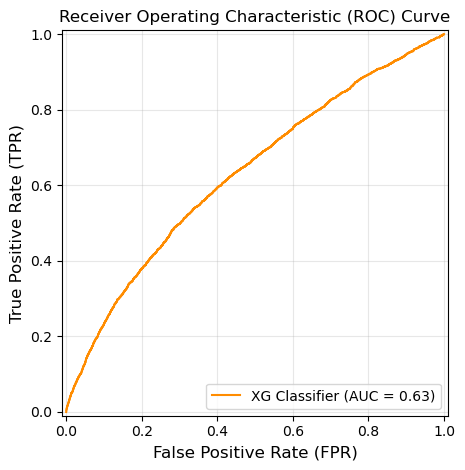

In [46]:

# Generate and plot the ROC Curve
plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay.from_estimator(xgboost_model, 
                                             test_predictors,
                                             test_target,
                                             name="XG Classifier",
                                             color="darkorange"
)

# Customizing the plot

plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=12)
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()




This plot represents the Receiver Operating Characteristic (ROC) curve for an XGBoost classifier. The key elements to note are:

True Positive Rate (TPR) (y-axis): Also called sensitivity or recall, this measures the proportion of actual positives correctly identified by the classifier.

False Positive Rate (FPR) (x-axis): This represents the proportion of negatives incorrectly classified as positives.

Area Under the Curve (AUC = 0.63): The AUC value summarizes the overall performance of the classifier. An AUC of 0.63 suggests the model has moderate discrimination ability between the classes, though it's not very strong.

### Gradient Boosting

In [47]:
# Initialize the Gradient Boosting model
gradient_boosting = GradientBoostingClassifier(random_state=1)

# Fit the model on the training data
gradient_boosting.fit(train_predictors, train_target)

# Predict on the test data
gradient_boosting_predictions = gradient_boosting.predict(test_predictors)


### Confusion Matrix for Gradient Boosting

In [48]:
# Compute the confusion matrix for the Gradient Boosting model
cm = confusion_matrix(test_target, gradient_boosting_predictions)
print('Confusion matrix\n', cm)

# Extract values from the confusion matrix
TP = cm[1, 1]  # True Positives: Correctly predicted positive cases
TN = cm[0, 0]  # True Negatives: Correctly predicted negative cases
FP = cm[0, 1]  # False Positives: Incorrectly predicted as positive
FN = cm[1, 0]  # False Negatives: Missed positive cases

# Print the values for each confusion matrix component
print('\nTrue Positives(TP) = ', TP)  # Display the number of true positives
print('\nTrue Negatives(TN) = ', TN)  # Display the number of true negatives
print('\nFalse Positives(FP) = ', FP)  # Display the number of false positives
print('\nFalse Negatives(FN) = ', FN)  # Display the number of false negatives

print('\nRecall Score {0:.4f}\n'.format(recall_score(test_target, gradient_boosting_predictions)))

print('Accuracy Score {0:.4f}\n'.format(accuracy_score(test_target, gradient_boosting_predictions)))

print('Precision Score {0:.4f}\n'.format(precision_score(test_target, gradient_boosting_predictions)))

print('F1 Score {0:.4f}\n'.format(f1_score(test_target, gradient_boosting_predictions)))

Confusion matrix
 [[16305  9311]
 [ 1348  1970]]

True Positives(TP) =  1970

True Negatives(TN) =  16305

False Positives(FP) =  9311

False Negatives(FN) =  1348

Recall Score 0.5937

Accuracy Score 0.6316

Precision Score 0.1746

F1 Score 0.2699



### ROC Curve for Gradient Boosting

<Figure size 800x600 with 0 Axes>

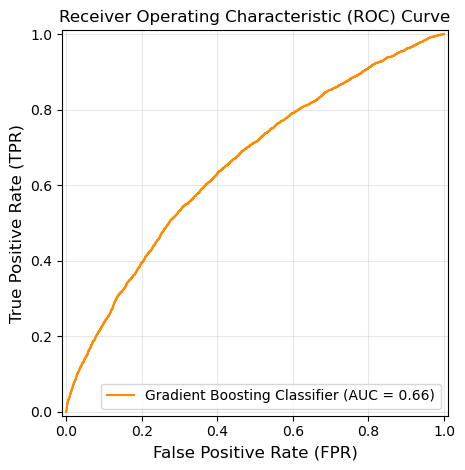

In [49]:


# Generate and plot the ROC Curve
plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay.from_estimator(
    gradient_boosting, 
    test_predictors, 
    test_target, 
    name="Gradient Boosting Classifier",
    color="darkorange"
)

# Customizing the plot

plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=12)
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()

This plot represents the Receiver Operating Characteristic (ROC) curve for a Gradient Boosting Classifier. Key observations:

True Positive Rate (TPR) (y-axis): The proportion of actual positives correctly classified (Recall or Sensitivity).

False Positive Rate (FPR) (x-axis): The proportion of actual negatives incorrectly classified as positives.

Area Under the Curve (AUC = 0.65):

AUC measures the ability of the model to distinguish between classes.
An AUC of 0.65 indicates a moderate level of performance, which is better than random guessing (AUC = 0.5) but not highly accurate.

### Hyperparamter Tuning for all models

In [50]:
param_grid_lr = {
    'solver': ['newton-cg', 'lbfgs', 'liblinear','sag', 'saga'],
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2', 'none'],
    'max_iter': [100, 500]
}
                      
param_grid_dt = {
    'criterion': ['gini', 'entropy','log_loss'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],           
    'max_features': [None, 'sqrt', 'log2'], 
}


param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Models
models = {
    'Logistic Regression': (LogisticRegression(random_state=1), param_grid_lr),
    'Decision Tree': (DecisionTreeClassifier(random_state=1), param_grid_dt),
    'XGBoost': (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=1), param_grid_xgb),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=1), param_grid_gb)
}

# Performing GridSearchCV for each model
best_models = {}

for model_name, (model, param_grid) in models.items():
    print(f"\nTuning hyperparameters for {model_name}...")
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1)
    grid_search.fit(train_predictors, train_target)

    print(f"Best Parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best Cross-Validation Accuracy for {model_name}: {grid_search.best_score_:.3f}")

    best_models[model_name] = grid_search.best_estimator_

# Evaluating the best models on the test set
for model_name, model in best_models.items():
    test_predictions = model.predict(test_predictors)
    print(f"\nTest Set Performance for {model_name}:")
    print(f"Accuracy: {accuracy_score(test_target, test_predictions):.3f}")
    print(f"Recall: {recall_score(test_target, test_predictions):.3f}")
    print(f"Precision: {precision_score(test_target, test_predictions):.3f}")
    print(f"F1 Score: {f1_score(test_target, test_predictions):.3f}")


Tuning hyperparameters for Logistic Regression...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters for Logistic Regression: {'C': 0.1, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy for Logistic Regression: 0.600

Tuning hyperparameters for Decision Tree...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters for Decision Tree: {'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Accuracy for Decision Tree: 0.934

Tuning hyperparameters for XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters for XGBoost: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best Cross-Validation Accuracy for XGBoost: 0.816

Tuning hyperparameters for Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters for Gradient Boosting: {'learning_rate':

In [51]:
column_names_predictors = [
    "patient_nbr", "race", "gender", "age", "admission_type_id",
    "discharge_disposition_id", "admission_source_id", "time_in_hospital",
    "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient",
    "number_diagnoses", "max_glu_serum", "metformin",
    "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide",
    "pioglitazone", "rosiglitazone", "acarbose", "miglitol",
    "troglitazone", "tolazamide", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone", "change", "diabetesMed", "Drug_change",
    "drug_count", "level1_diagnosis1"
]
column_names_target = ["readmitted"]
train_predictors_df = pd.DataFrame(train_predictors, columns=column_names_predictors)
test_predictors_df = pd.DataFrame(test_predictors, columns=column_names_predictors )
train_target_df = pd.DataFrame(train_target, columns=column_names_target )
test_target_df = pd.DataFrame(test_target, columns=column_names_target )
test_predictors_df.head()

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,Drug_change,drug_count,level1_diagnosis1
0,-1.353271,0.395471,-0.924401,-1.354791,-0.533185,-0.446583,0.467074,2.878484,1.730040,-0.787961,...,-0.083071,-0.011611,-0.00322,0.0,-0.00322,-0.929950,0.546110,-0.589967,-0.199480,-0.419324
1,-1.035633,-1.927402,-0.924401,-0.713529,-0.533185,3.735084,0.467074,-0.139306,0.203841,-0.787961,...,-0.083071,-0.011611,-0.00322,0.0,-0.00322,1.075326,0.546110,1.456647,1.966590,-0.419324
2,0.885969,0.395471,-0.924401,-0.713529,-0.533185,-0.446583,0.467074,-0.139306,0.000348,-0.787961,...,-0.083071,-0.011611,-0.00322,0.0,-0.00322,-0.929950,-1.831131,-0.589967,-1.282515,-0.923369
3,-0.751931,0.395471,1.081782,1.210257,2.684406,3.735084,2.239513,0.196004,-0.864498,-0.787961,...,-0.083071,-0.011611,-0.00322,0.0,-0.00322,1.075326,0.546110,1.456647,1.966590,2.604949
4,-1.315547,0.395471,1.081782,0.568995,-0.533185,3.735084,0.467074,-0.809926,0.305588,-0.200823,...,-0.083071,-0.011611,-0.00322,0.0,-0.00322,-0.929950,-1.831131,-0.589967,-1.282515,0.588767


### Comparision of Accuracy, Precision and Recall for all models

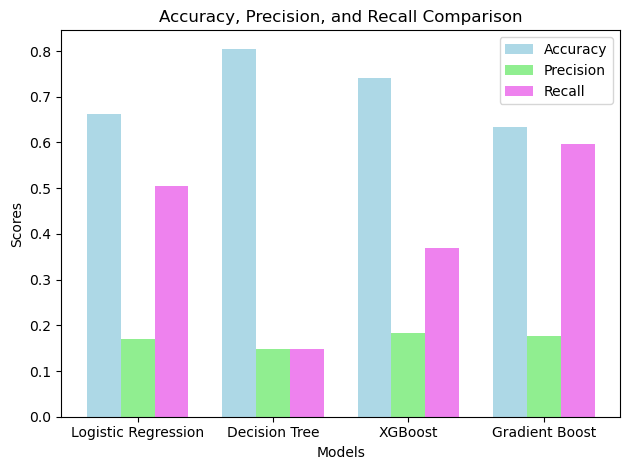

In [52]:
# Data
models = ['Logistic Regression', 'Decision Tree', 'XGBoost', 'Gradient Boost']
accuracy = [0.663, 0.805, 0.740, 0.6338]
recall = [0.505, 0.148, 0.370, 0.597]
precision = [0.171, 0.148, 0.184, 0.1762]

# Bar width and positions
bar_width = 0.25
x = np.arange(len(models))

# Plotting
plt.bar(x - bar_width, accuracy, width=bar_width, label='Accuracy', color='lightblue')
plt.bar(x, precision, width=bar_width, label='Precision', color='lightgreen')
plt.bar(x + bar_width, recall, width=bar_width, label='Recall', color='violet')

# Labels and title
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Accuracy, Precision, and Recall Comparison')
plt.xticks(x, models)
plt.legend()

# Display
plt.tight_layout()
plt.show()

### Shap Analysis for Logistic Regression

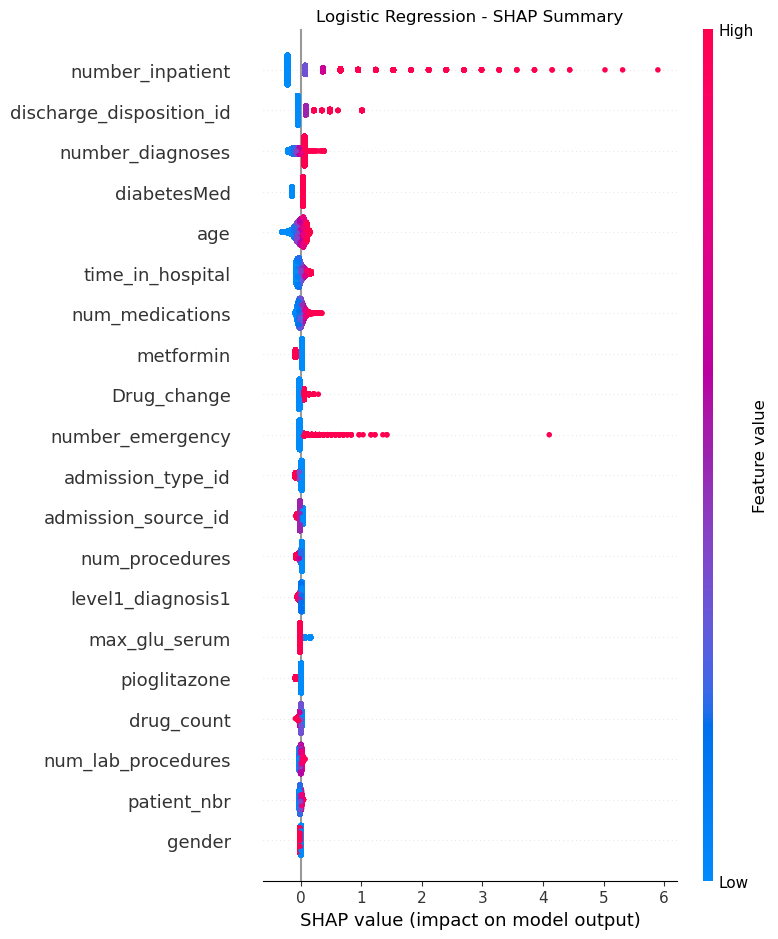

In [53]:
lr_params = {'C': 0.01, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
lr_model = LogisticRegression(**lr_params)
lr_model.fit(train_predictors_df, train_target_df)


lr_explainer = shap.LinearExplainer(lr_model, train_predictors_df)
lr_shap_values = lr_explainer.shap_values(test_predictors_df)

plt.title("Logistic Regression - SHAP Summary")
shap.summary_plot(lr_shap_values,  test_predictors,feature_names=test_predictors_df.columns, show=True,plot_type="dot")

plt.show() 



### Shap Analysis for Decision Tree Model

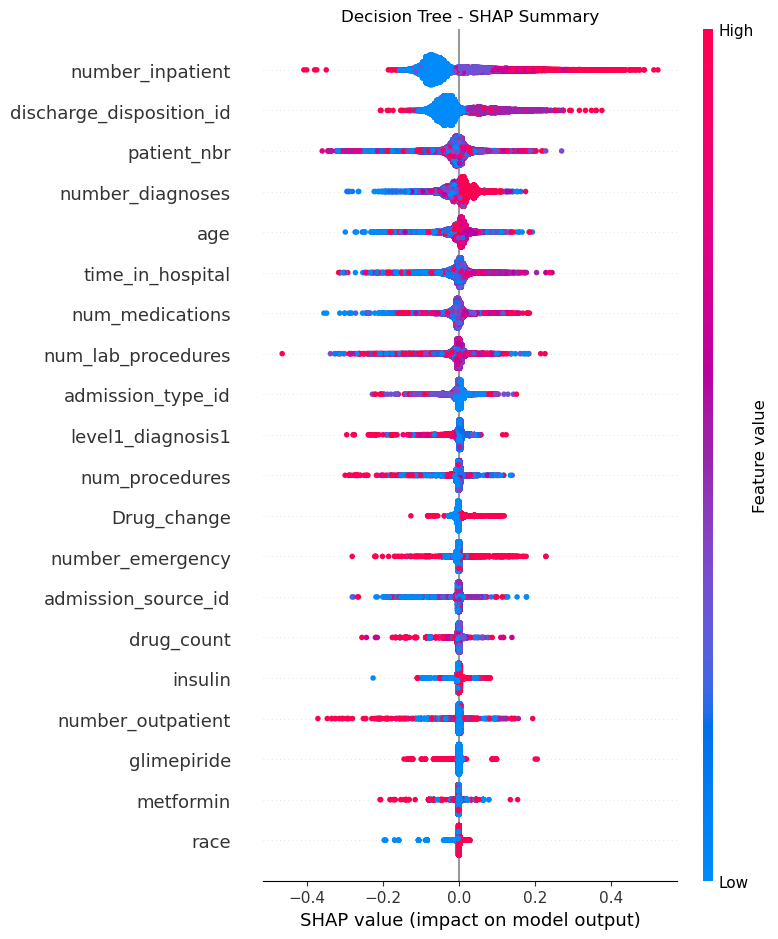

In [54]:
# Setting up the Decision Tree model with the best parameters
dt_params = {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 20}
dt_model = DecisionTreeClassifier(**dt_params)
dt_model.fit(train_predictors_df, train_target_df)
# Generating SHAP values
dt_explainer = shap.TreeExplainer(dt_model)
dt_shap_values = dt_explainer.shap_values(test_predictors_df)
dt_shap_values_class_1 = dt_shap_values[:,:,1]
# Creating SHAP summary plot for Decision Tree
plt.title("Decision Tree - SHAP Summary")
shap.summary_plot(dt_shap_values_class_1, test_predictors_df, feature_names=test_predictors_df.columns, show=False)

plt.show()


### Shap Analysis for XGboost Model

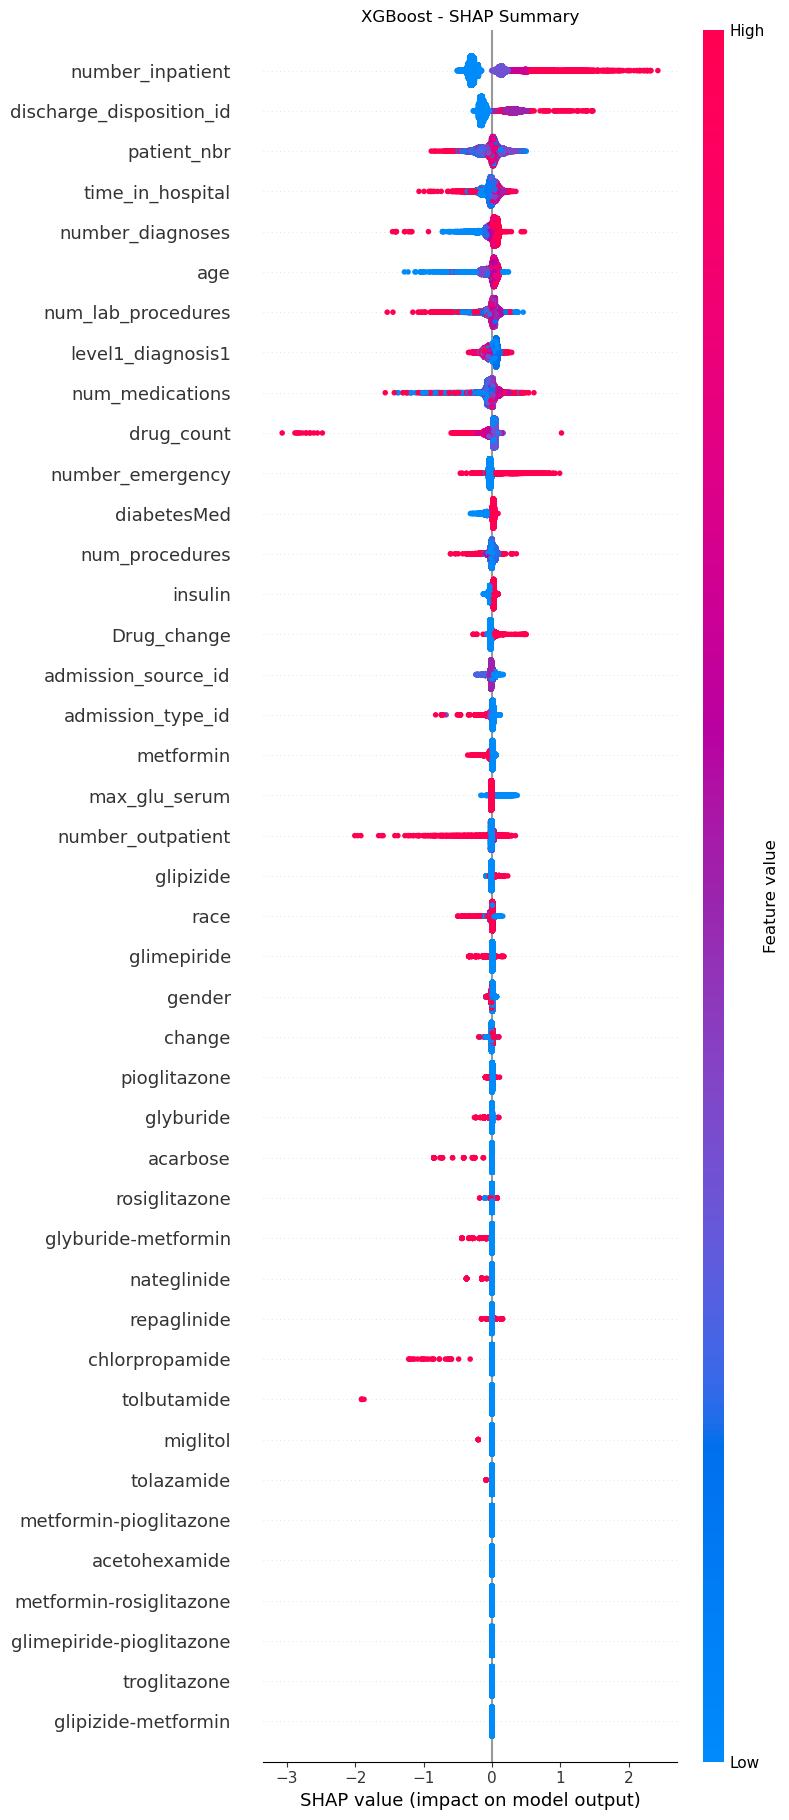

In [55]:
import xgboost as xgb

# Setting up the XGBoost model with the best parameters
xgb_params = {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(train_predictors_df, train_target_df)

import shap
# Generating SHAP values
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(test_predictors_df)

# Creating SHAP summary plot for XGBoost
plt.title("XGBoost - SHAP Summary")
shap.summary_plot(xgb_shap_values, test_predictors_df, feature_names=test_predictors_df.columns, max_display=42, show=True, plot_type="dot")

plt.show()


### Shap Analysis for GradientBoostingClassifier

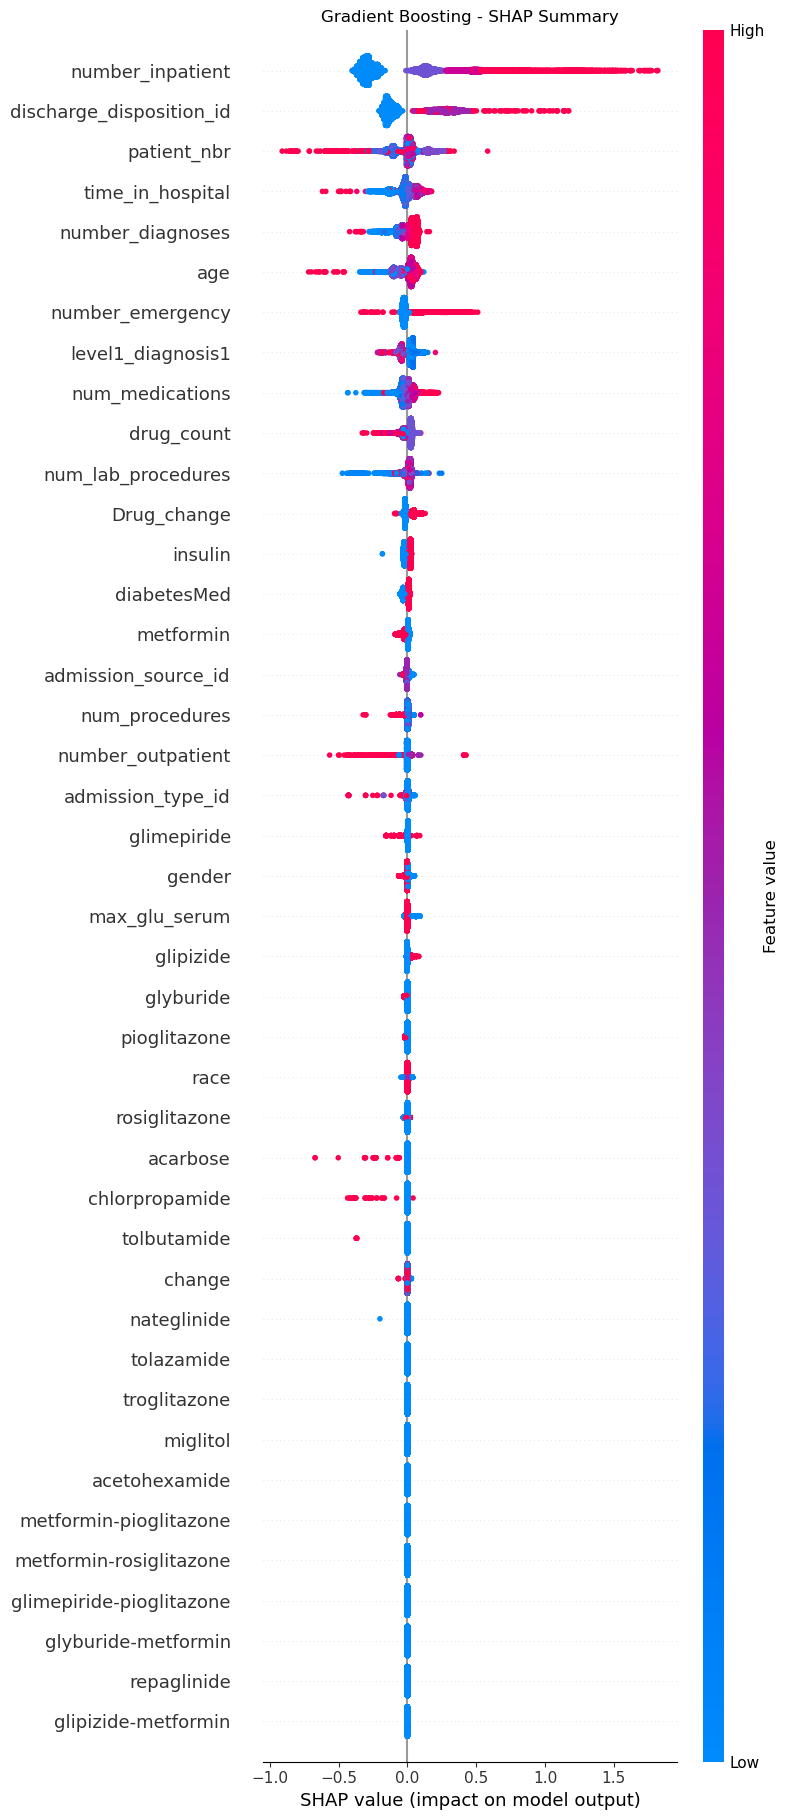

In [56]:
from sklearn.ensemble import GradientBoostingClassifier

# Setting up the Gradient Boosting model with the best parameters
#gb_params = {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
gb_model = GradientBoostingClassifier(random_state=1)
gb_model.fit(train_predictors_df, train_target_df)

# Generating SHAP values
gb_explainer = shap.TreeExplainer(gb_model)
gb_shap_values = gb_explainer.shap_values(test_predictors_df)

# Creating SHAP summary plot for Gradient Boosting
plt.title("Gradient Boosting - SHAP Summary")
shap.summary_plot(gb_shap_values, test_predictors_df, feature_names=test_predictors_df.columns, max_display=42, show=True, plot_type="dot")

plt.show()


### Results and Findings

After exploring multiple machine learning models to predict diabetic patient readmission within 30 days, the Gradient Boosting Model was chosen as the optimal predictor. This selection is based on its high recall and robust overall performance.

In the healthcare industry, recall is a critical metric, as it ensures that patients who may require urgent readmission are accurately identified, thereby preventing potential life-threatening situations. This proactive approach reduces costs, enhances hospital efficiency, and improves patient care outcomes.

By leveraging this predictive model, hospitals can refine their strategies, optimize resource allocation, and maintain a strong reputation for quality care. Ultimately, this approach prioritizes better patient care while achieving cost-effective operations.
